In [7]:
!export CUDNN_PATH=$(dirname $(python3.12 -c "import nvidia.cudnn;print(nvidia.cudnn.__file__)"))
!export LD_LIBRARY_PATH=$LD_LIBRARY_PATH:$CONDA_PREFIX/lib

In [8]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
_dataset = keras.utils.image_dataset_from_directory('./datasets/cifar10/train', image_size=(32, 32), batch_size=1000, shuffle=False, label_mode='int')

mean    = tf.zeros(3)
sq_mean = tf.zeros(3)
n_pixels = 0

for images, _ in _dataset:
    images = tf.cast(images, tf.float32) / 255.0  # [0, 255] -> [0.0, 1.0]
    b, h, w, c = images.shape  # NHWC
    n_pixels += b * h * w
    mean     += tf.reduce_sum(images, axis=[0, 1, 2])  # N, H, W -> (C,)
    sq_mean  += tf.reduce_sum(images ** 2, axis=[0, 1, 2])

mean = mean / n_pixels
std  = tf.sqrt(sq_mean / n_pixels - mean ** 2)  # Var(X) = E[X²] - E[X]²

print(mean.numpy(), std.numpy())

Found 50000 files belonging to 10 classes.
[0.49145442 0.48224497 0.4467191 ] [0.246782   0.24316452 0.2611615 ]


In [10]:
# CIFAR-10 channel-wise(R, G, B) mean/std
MEAN = tf.constant([0.4914, 0.4822, 0.4465], dtype=tf.float32)
STD  = tf.constant([0.2470, 0.2435, 0.2616], dtype=tf.float32)

# image_dataset_from_directory: sub-folder name을 class로 자동 인식 (a-z 정렬)
# label_mode='int': 정수 레이블 반환 (SparseCategoricalCrossentropy)
# image_size: 원본 CIFAR-10은 32×32이므로 resize 없이 load
train_dataset = keras.utils.image_dataset_from_directory('./datasets/cifar10/train', image_size=(32, 32), batch_size=64, shuffle=True, label_mode='int')
test_dataset = keras.utils.image_dataset_from_directory('./datasets/cifar10/test', image_size=(32, 32), batch_size=64, shuffle=False, label_mode='int')

print(train_dataset.class_names)

Found 50000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [11]:
# keras.Sequential로 데이터 증강 레이어 구성
# Sequential 증강 레이어는 .fit() 중에만 활성화되고, .evaluate(), .predict() 시에는 비활성화 된다
data_augmentation = keras.Sequential([
    # 4px zero-padding 후 32×32 random crop -> 물체 위치 다양화
    layers.ZeroPadding2D(padding=4),
    layers.RandomCrop(32, 32),

    # 50% 확률 좌우 반전
    layers.RandomFlip("horizontal"),

    # 밝기 및 대비 ±20% 랜덤화
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2),
], name="augmentation")

In [12]:
def normalize(image, label):
    # uint8(0 ~ 255) -> float32(0.0 ~ 1.0) Normalization
    image = tf.cast(image, tf.float32) / 255.0
    # 채널별 표준화: (pixel - mean) / std
    image = (image - MEAN) / STD
    return image, label

# map(): 각 배치에 전처리 함수 적용
# prefetch(): 다음 batch를 background에서 미리 load -> GPU 대기 시간 감소
train_dataset = train_dataset.map(normalize, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
test_dataset  = test_dataset.map(normalize,  num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

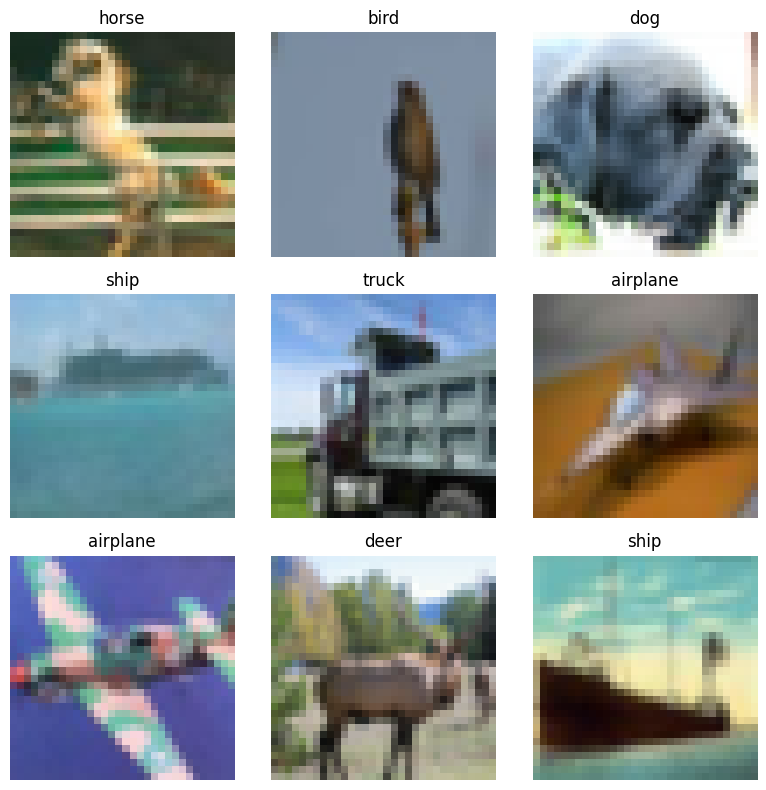

In [13]:
CLASSES = ("airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck")

# 역정규화denormalize): 표준화 전 원본 픽셀값으로 복원
# STD, MEAN이 tf.constant이므로 .numpy()로 변환
def denormalize(img):
    return np.clip(img * STD.numpy() + MEAN.numpy(), 0, 1)

# 학습셋에서 배치 하나 추출
sample_images, sample_labels = next(iter(train_dataset))

figure = plt.figure(figsize=(8, 8))
indices = np.random.choice(sample_images.shape[0], 9, replace=False)

for i, idx in enumerate(indices, 1):
    img   = denormalize(sample_images[idx].numpy())
    label = sample_labels[idx].numpy()
    figure.add_subplot(3, 3, i)
    plt.title(CLASSES[label])
    plt.axis("off")
    plt.imshow(img)

plt.tight_layout()
plt.show()

**Conv2D(filters, kernel_size, padding, strides)**
* **filters**: 시작은 32 또는 64, 깊어질수록 2배씩 증가 (32→64→128→256), 깊어질수록 더 복잡한 feature가 많아짐
* **kernel_size**: 일반적으로 3 (3×3)
* **padding**: 'same' 이면 출력 크기 유지 (kernel=3 일 때 padding=1 과 동일)
* **strides**: 일반적으로 1, 크기를 줄이려면 2

**BatchNormalization()**
* 이전 Conv2D의 filters 수에 맞춰 자동 설정됨

**MaxPooling2D(pool_size)**
* **pool_size**: 일반적으로 2, feature map을 절반으로 감소 (32→16→8→4)

**Dense(units)**
* **units**: 점진적으로 1/2로 감소, 마지막 Dense는 class 수 (CIFAR-10: 10)

**GlobalAveragePooling2D()**
* Flatten 대신 사용 시 파라미터 수를 크게 줄일 수 있음 (H×W×C -> C 로 공간 평균, Flatten은 H×W×C -> H*W*C)

In [14]:
def CNN():
    inputs = keras.Input(shape=(32, 32, 3))

    # Data Augmentation (학습 시에만 적용)
    x = data_augmentation(inputs)

    # Block 1
    x = layers.Conv2D(64, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(64, 3, padding="same", use_bias=False)(x)  # 동일 channel로 더 자세한 패턴 학습
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(2)(x)  # 32×32 → 16×16

    # Block 2
    x = layers.Conv2D(128, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(128, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(2)(x)  # 16×16 → 8×8

    # Block 3
    x = layers.Conv2D(256, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(256, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(2)(x)  # 8×8 → 4×4

    # Classifier
    x = layers.GlobalAveragePooling2D()(x)  # 4×4×256 → 256 (GAP, 공간 평균)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)  # 학습 중 50% 뉴런 무작위 비활성화 -> 과적합 방지
    outputs = layers.Dense(10)(x)  # logits (softmax는 loss 함수 내부에서 처리)

    return keras.Model(inputs, outputs, name="cnn_cifar10")


model = CNN()
model.summary()

Model: "cnn_cifar10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       589,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 8, 8, 256)      │             

 Total params: 1,216,458 (4.64 MB)

 Trainable params: 1,214,666 (4.63 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [15]:
# Adam optimizer + SparseCategoricalCrossentropy
# from_logits=True: 모델 출력이 class (softmax 미적용) 임을 명시
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0007),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

callbacks = [
    # val_loss가 5 epoch 동안 개선되지 않으면 학습 조기 종료
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True  # 가장 좋은 가중치로 자동 복원
    ),
    # val_loss가 개선되지 않으면 learning rate를 0.5배로 감소
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=0.000001,
        verbose=1
    ),
]

In [ ]:
EPOCHS = 30

history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=test_dataset,
    callbacks=callbacks,
)

Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 270s 341ms/step - accuracy: 0.0973 - loss: 2.3196 - val_accuracy: 0.1000 - val_loss: 2.3026 - learning_rate: 7.0000e-04
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - accuracy: 0.0978 - loss: 2.3027

In [ ]:
hist = history.history

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss graph
ax1.plot(hist["loss"],     label="Train Loss")
ax1.plot(hist["val_loss"], label="Val Loss")
ax1.set_title("Loss Curve")
ax1.set_xlabel("Epoch")
ax1.legend()

# Accuracy graph
ax2.plot(hist["accuracy"],     label="Train Acc")
ax2.plot(hist["val_accuracy"], label="Val Acc")
ax2.set_title("Accuracy Curve")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(test_dataset, verbose=0)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

all_preds  = []
all_labels = []

for images, labels in test_dataset:
    logits    = model(images, training=False)  # training=False: disable Dropout
    preds     = tf.argmax(logits, axis=1).numpy()
    all_preds.extend(preds)
    all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASSES, yticklabels=CLASSES,
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# 테스트셋에서 이미지 하나 추출
sample_images, sample_labels = next(iter(test_dataset))

idx = 0
single_image = sample_images[idx:idx+1]  # (1, 32, 32, 3) 유지
true_label   = sample_labels[idx].numpy()

logits      = model(single_image, training=False)
probs       = tf.nn.softmax(logits, axis=1).numpy()[0]
pred_label  = np.argmax(probs)
confidence  = probs[pred_label]

# 역정규화 후 시각화
img = denormalize(single_image[0].numpy())

plt.imshow(img)
plt.title(
    f"true: {CLASSES[true_label]} | "
    f"pred: {CLASSES[pred_label]} | "
    f"conf: {confidence:.2%}"
)
plt.axis(False)
plt.show()